<a href="https://colab.research.google.com/github/Malicef/Sistemas-Inteligentes/blob/main/projeto4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Disciplina: PAM0466– SISTEMAS INTELIGENTES

Docente: Pedro Thiago Valerio de Souza

Discentes: Maria Alice Ferreira Teixeira e Thiago Luan Moreira Sousa

4ª PROJETO

## Objetivo

Este projeto tem como objetivo implementar uma rede Adaline para classificar sinais de radar ionosférico utilizando o dataset Ionosphere, disponível no repositório UCI Machine Learning Repository.

A proposta consiste em distinguir sinais classificados como “good”, que representam estruturas ionosféricas coerentes, de sinais “bad”, associados à ausência de estrutura ou presença de interferências.

Ao longo do trabalho serão realizados:
- pré-processamento dos dados;
- normalização utilizando Z-score;
- estudo da taxa de aprendizagem da Adaline;
- análise da convergência da função de perda;
- avaliação do desempenho do modelo por meio de métricas de classificação.

# Importação das Bibliotecas

Nesta etapa são importadas as bibliotecas necessárias para:
- manipulação numérica dos dados;
- visualização gráfica;
- pré-processamento;
- treinamento da rede Adaline;
- cálculo das métricas de avaliação.

Também são ocultados avisos de convergência gerados durante os experimentos com diferentes taxas de aprendizagem.

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suprimindo ConvergenceWarnings que poluem o output durante o estudo de etas
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Preparação dos Dados

Inicialmente o dataset Ionosphere é carregado a partir da biblioteca `ucimlrepo`.

Em seguida:
- os rótulos são recodificados para valores bipolares:
  - good → +1
  - bad → -1
- atributos constantes são removidos;
- os dados são normalizados utilizando padronização Z-score;
- o conjunto é dividido em treino e teste utilizando divisão estratificada.

In [ ]:
# Carregar o dataset
ionosphere = fetch_ucirepo(id=52)
X = ionosphere.data.features
y = ionosphere.data.targets


def recode(target_class):
    return 1 if target_class == "g" else -1


y = y["Class"].apply(recode).to_frame()

# Remover atributos constantes (Atributo 2 no Ionosphere é todo zero)
X = X.loc[:, X.nunique() > 1]

# Normalização Z-score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divisão Estratificada (80% Treino / 20% Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y.values.ravel(), test_size=0.2, random_state=42, stratify=y
)

print(f"Dados originais: {ionosphere.data.features.shape[1]} colunas")
print(f"Dados após remover constantes: {X.shape[1]} colunas")

Dados originais: 34 colunas
Dados após remover constantes: 33 colunas


## Justificativa Algébrica da Normalização

A normalização dos dados é necessária para garantir estabilidade no treinamento da rede Adaline.

A regra Delta atualiza os pesos utilizando o gradiente do Erro Quadrático Médio (MSE). Quando os atributos possuem escalas muito diferentes, alguns atributos passam a dominar o gradiente, provocando oscilações, instabilidade numérica e dificuldade de convergência.

A padronização Z-score é definida por:

$$
z = \frac{x - \mu}{\sigma}
$$

onde:
- $\mu$ representa a média;
- $\sigma$ representa o desvio padrão.

Após a normalização, os atributos passam a possuir média próxima de zero e desvio padrão unitário, tornando a superfície de erro mais uniforme e permitindo que a taxa de aprendizagem atue de maneira mais estável e eficiente.

Dessa forma, a convergência da regra Delta ocorre de maneira mais rápida e menos suscetível à divergência.

# Estudo da Taxa de Aprendizagem

Nesta etapa são avaliados diferentes valores da taxa de aprendizagem ($\eta$) da rede Adaline.

Foram testados os seguintes valores:

- $10^{-4}$
- $10^{-3}$
- $10^{-2}$
- $5 \times 10^{-2}$
- $10^{-1}$

Para cada configuração:
- o modelo foi treinado durante 200 épocas;
- a função de perda (MSE) foi registrada;
- a curva de convergência foi analisada.

O objetivo é identificar o valor de $\eta$ que apresenta convergência mais estável e menor erro final.

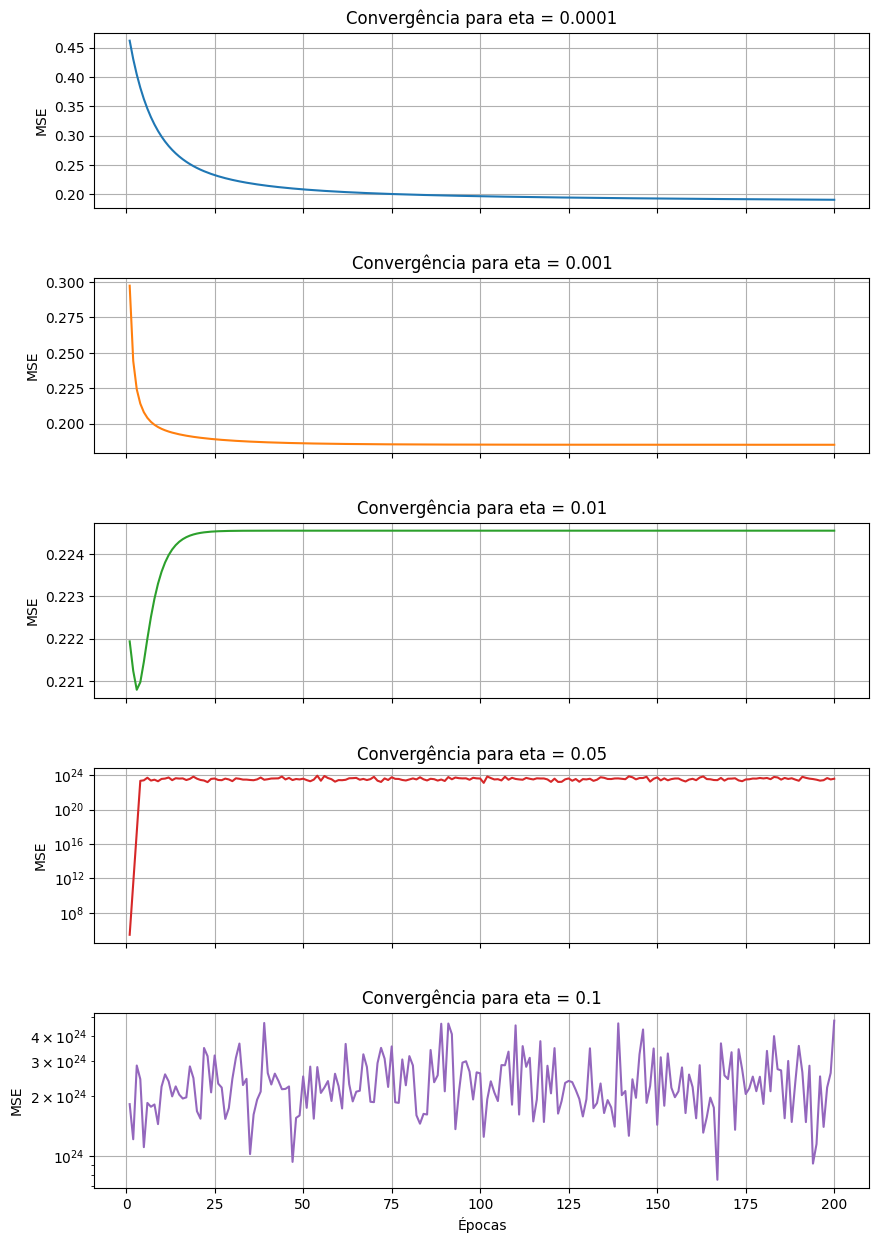

O melhor eta identificado foi: 0.001 com perda final de 0.1852


In [ ]:
etas = [10**-4, 10**-3, 10**-2, 5 * 10**-2, 10**-1]
n_epochs = 200
history_per_eta = {}

fig, axes = plt.subplots(len(etas), 1, figsize=(10, 15), sharex=True)
fig.subplots_adjust(hspace=0.4)

best_final_loss = float("inf")
best_eta = 0.0

for i, eta in enumerate(etas):
    model = SGDClassifier(
        loss="squared_error",
        learning_rate="constant",
        eta0=eta,
        max_iter=1,
        warm_start=True,
        random_state=42,
    )

    losses = []
    for epoch in range(n_epochs):
        model.fit(X_train, y_train)
        y_val_cont = np.dot(X_train, model.coef_[0]) + model.intercept_
        mse = np.mean((y_train - y_val_cont) ** 2) / 2
        losses.append(mse)

    history_per_eta[eta] = losses
    if losses[-1] < best_final_loss:
        best_final_loss = losses[-1]
        best_eta = eta

    axes[i].plot(range(1, n_epochs + 1), losses, label=f"eta = {eta}", color=f"C{i}")
    axes[i].set_title(f"Convergência para eta = {eta}")
    axes[i].set_ylabel("MSE")
    axes[i].grid(True)
    if eta >= 0.05:
        axes[i].set_yscale("log")

axes[-1].set_xlabel("Épocas")
plt.show()

print(f"O melhor eta identificado foi: {best_eta} com perda final de {best_final_loss:.4f}")

## Análise das Curvas de Convergência

Os resultados mostram que a taxa de aprendizagem influencia diretamente a estabilidade do treinamento da rede Adaline.

A taxa $\eta = 10^{-4}$ apresentou convergência lenta, reduzindo gradualmente o erro ao longo das épocas.

Já o valor $\eta = 10^{-3}$ apresentou a melhor estabilidade e o menor erro final, convergindo rapidamente sem oscilações significativas.

A taxa $\eta = 10^{-2}$ também apresentou estabilidade, porém convergiu para um erro final ligeiramente superior.

Por outro lado, taxas mais elevadas, como $5 \times 10^{-2}$ e $10^{-1}$, provocaram divergência da função de perda, gerando valores extremamente altos de erro e instabilidade no treinamento.

Dessa forma, o valor $\eta = 0.001$ foi selecionado como a melhor taxa de aprendizagem para o problema proposto.

# Avaliação Final do Modelo

Após a definição da melhor taxa de aprendizagem, o modelo Adaline foi treinado novamente utilizando todo o conjunto de treino.

Em seguida, foram realizadas predições sobre o conjunto de teste e calculadas as seguintes métricas:
- acurácia;
- precisão;
- recall;
- F1-score;
- matriz de confusão.

--- Métricas Finais (eta=0.001) ---
Acurácia  : 0.9577
Precisão  : 0.9388
Recall    : 1.0000
F1-Score  : 0.9684


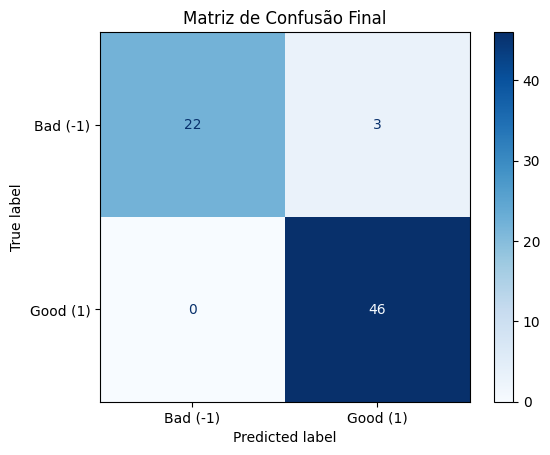

In [ ]:
# Treinando o modelo final com o melhor eta encontrado
final_model = SGDClassifier(
    loss="squared_error",
    learning_rate="constant",
    eta0=best_eta,
    max_iter=n_epochs,
    random_state=42,
)
final_model.fit(X_train, y_train)

# Realizando predições no conjunto de teste
y_pred = final_model.predict(X_test)

# Cálculo das métricas
print(f"--- Métricas Finais (eta={best_eta}) ---")
print(f"Acurácia  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão  : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Bad (-1)", "Good (1)"]
)
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão Final")
plt.show()

## Análise das Métricas

Os resultados obtidos demonstram que a rede Adaline apresentou excelente desempenho na classificação dos sinais ionosféricos.

A acurácia de aproximadamente 95,77% indica que o modelo classificou corretamente a grande maioria das amostras do conjunto de teste.

O recall igual a 1.0 demonstra que todas as amostras da classe positiva (“good”) foram corretamente identificadas, sem ocorrência de falsos negativos para essa classe.

A precisão de aproximadamente 93,88% indica que poucas amostras foram classificadas incorretamente como positivas.

A matriz de confusão confirma esse comportamento, mostrando apenas três erros de classificação no conjunto de teste, evidenciando a boa capacidade de generalização do modelo.

# Discussão Sobre o Erro Mais Crítico

Considerando que a classe bad (-1) representa ausência de estrutura ionosférica coerente ou presença de interferências, o erro de classificação mais crítico é o Falso Positivo.

Esse erro ocorre quando um sinal bad é classificado incorretamente como good.

Em aplicações reais de telecomunicações e navegação, isso poderia levar o sistema a considerar válido um sinal corrompido ou instável, comprometendo a confiabilidade da comunicação ou do posicionamento.

Já um Falso Negativo, embora resulte na perda temporária de um dado válido, tende a ser menos perigoso do que utilizar informações incorretas em sistemas críticos.

# Conclusão

A rede Adaline mostrou-se adequada para a classificação do dataset Ionosphere, alcançando métricas elevadas de desempenho.

O estudo da taxa de aprendizagem demonstrou que a escolha adequada de $\eta$ é fundamental para garantir estabilidade e boa convergência durante o treinamento.

Além disso, a normalização dos dados utilizando Z-score foi essencial para evitar problemas numéricos e melhorar a eficiência do algoritmo.

Apesar de sua simplicidade e natureza linear, a Adaline conseguiu modelar adequadamente o problema proposto. Entretanto, para cenários mais complexos e não lineares, arquiteturas mais sofisticadas poderiam apresentar desempenho superior.